# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

Import and set magics:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dstapi import DstApi

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import dataproject

Matplotlib is building the font cache; this may take a moment.


## Question 1

# 1.1 The Gini coefficient and the top 10 percent share

In [ ]:
# a. connect to the two tables
ifor41 = DstApi('IFOR41')   # inequality measures, incl. the Gini coefficient
ifor32 = DstApi('IFOR32')   # average income by decile group

# b. inspect what the tables contain
for name, tab in [('IFOR41', ifor41), ('IFOR32', ifor32)]:
    print('=' * 60)
    print(name)
    print('=' * 60)
    print(tab.tablesummary(language='en'))

IFOR41
Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00
  variable name  # values First value First value label Last value  \
0         ULLIG         4          70  Gini coefficient         73   
1     KOMMUNEDK        99         000       All Denmark        851   
2           Tid        38        1987              1987       2024   

                                  Last value label  Time variable  
0  P90/10 (Upper decile boundary divided by lower)          False  
1                                          Aalborg          False  
2                                             2024           True  
IFOR32
Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00
  variable name  # values First value First value label Last value  \
0      DECILGEN        10         1DC       First decil       10DC   
1     KOMMUNEDK 

In [4]:
# a. IFOR41: the Gini coefficient (ULLIG=70) for all of Denmark (KOMMUNEDK=000), all years
params41 = ifor41.define_base_params(language='en')
for var in params41['variables']:
    code = var['code'].upper()
    if code == 'ULLIG':       var['values'] = ['70']
    elif code == 'KOMMUNEDK': var['values'] = ['000']
    elif code == 'TID':       var['values'] = ['*']

gini_raw = ifor41.get_data(params=params41)
print('IFOR41:', gini_raw.shape)
print(gini_raw.head(3))
print()

# b. IFOR32: average income in all ten decile groups, all of Denmark, all years
params32 = ifor32.define_base_params(language='en')
for var in params32['variables']:
    code = var['code'].upper()
    if code == 'DECILGEN':    var['values'] = ['*']
    elif code == 'KOMMUNEDK': var['values'] = ['000']
    elif code == 'TID':       var['values'] = ['*']

dec_raw = ifor32.get_data(params=params32)
print('IFOR32:', dec_raw.shape)
print(dec_raw.head(3))

IFOR41: (38, 4)
              ULLIG    KOMMUNEDK   TID INDHOLD
0  Gini coefficient  All Denmark  2016   28.97
1  Gini coefficient  All Denmark  1999   23.83
2  Gini coefficient  All Denmark  1988   22.06

IFOR32: (380, 4)
       DECILGEN    KOMMUNEDK   TID  INDHOLD
0   First decil  All Denmark  2013    75704
1  Second decil  All Denmark  2013   140049
2   Third decil  All Denmark  2013   163582


In [5]:
# a. clean IFOR41: one row per year with the Gini coefficient
gini = (gini_raw
        .rename(columns={'TID':'year', 'INDHOLD':'gini'})
        .loc[:, ['year','gini']]
        .astype({'year':int, 'gini':float})
        .sort_values('year')
        .reset_index(drop=True))

# b. clean IFOR32: one row per year and decile group
dec = (dec_raw
       .rename(columns={'TID':'year', 'INDHOLD':'mean_income', 'DECILGEN':'decile'})
       .loc[:, ['year','decile','mean_income']]
       .astype({'year':int, 'mean_income':float}))

# c. the top 10 pct. share: mean income in the 10th decile relative to the sum of all deciles
total = dec.groupby('year')['mean_income'].sum()
top   = dec[dec['decile'].str.contains('tenth', case=False)].set_index('year')['mean_income']
assert len(top) == len(total), 'the top decile group was not identified correctly'

top10 = (100*top/total).rename('top10').reset_index()

# d. merge, checking that no rows are duplicated
data = pd.merge(gini, top10, on='year', validate='1:1')

print(data.head(3))
print(data.tail(3))
print('correlation:', round(data['gini'].corr(data['top10']), 3))

   year   gini      top10
0  1987  22.07  18.454866
1  1988  22.06  18.428870
2  1989  21.93  18.495170
    year   gini      top10
35  2022  29.96  24.357469
36  2023  30.61  25.282340
37  2024  30.43  25.121443
correlation: 0.982


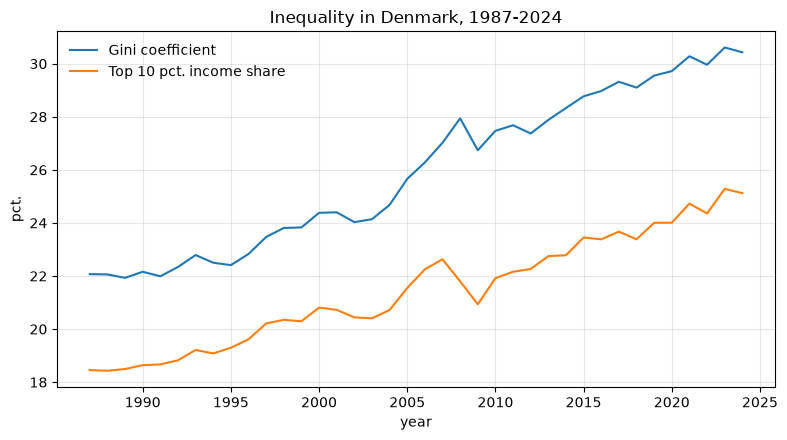

In [7]:
fig, ax = plt.subplots(figsize=(8,4.5))

ax.plot(data['year'], data['gini'],  label='Gini coefficient')
ax.plot(data['year'], data['top10'], label='Top 10 pct. income share')

ax.set_xlabel('year')
ax.set_ylabel('pct.')
ax.set_title('Inequality in Denmark, 1987-2024')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()